# Boosting - Customer Churn

**Name:** Satheesh B  
**Roll No:** 24BAD107

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

## Load Dataset

In [2]:
df = pd.read_csv("churn_boosting.csv")
df.head()

,Tenure,MonthlyCharges,ContractType,InternetService,Churn
0,65,105.22,Two year,NaN,0
1,17,75.19,Month-to-month,NaN,0
2,71,76.09,Two year,Fiber optic,0
3,45,107.67,Two year,Fiber optic,0
4,4,60.35,Two year,NaN,0


## Encoding

In [3]:
le = LabelEncoder()
df['ContractType'] = le.fit_transform(df['ContractType'])
df['Churn'] = le.fit_transform(df['Churn'])

## Define Features and Target

In [4]:
X = df[['Tenure','MonthlyCharges','ContractType']]
y = df['Churn']

## Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Train Models

In [6]:
ada = AdaBoostClassifier(n_estimators=50)
gb = GradientBoostingClassifier(n_estimators=50)

ada.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=50)

## Accuracy

In [7]:
print("AdaBoost:", accuracy_score(y_test, ada.predict(X_test)))
print("Gradient Boosting:", accuracy_score(y_test, gb.predict(X_test)))

AdaBoost: 1.0
Gradient Boosting: 1.0


## ROC Curve

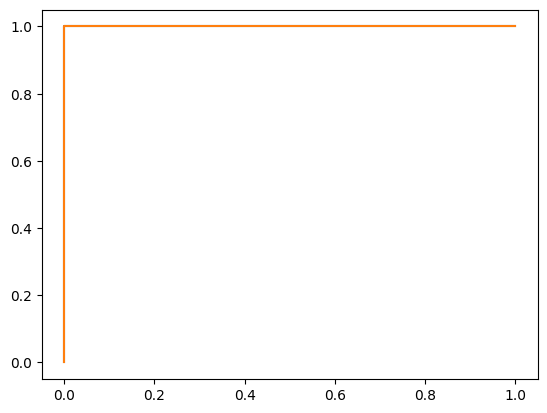

In [8]:
y_prob_ada = ada.predict_proba(X_test)[:,1]
y_prob_gb = gb.predict_proba(X_test)[:,1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr_ada, tpr_ada)
plt.plot(fpr_gb, tpr_gb)
plt.show()